# ЛР 1.1: Парная регрессия

# **Теоретическая часть**

In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


x0 = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y0 = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

### Полигон значений

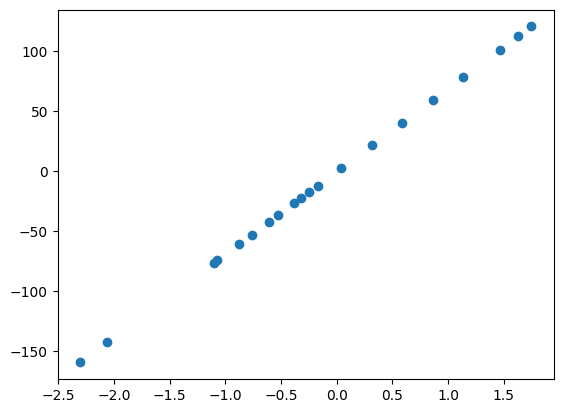

In [118]:
plt.figure()
plt.scatter(x, y)
plt.show()

### **Создание класса для обучения**

In [119]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self): # Конструктор (задет начальные коэффициенты по 0)
        self.b0 = 0
        self.b1 = 0

    def predict(self, x): # Функция предсказывания с вычисленными коэффициентами
        return self.b0 + self.b1 * x

    def error(self, X, Y): # Функция вычисления СКО-ошибки
        return sum((self.predict(X) - Y) ** 2) / (2 * len(X))

    def fit(self, X, Y): # Обучение (выравнивание коэффициентов под наши значения)
        alpha = 0.1 # Скорость обучения
        dJ0 = sum(self.predict(X) - Y) /len(X)
        dJ1 = sum((self.predict(X) - Y) * X) /len(X)
        self.b0 -= alpha * dJ0
        self.b1 -= alpha * dJ1


hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("Начальная ошибка:", J)

0
0
Начальная ошибка: 2937.6446095153397


### **Создание объекта** (СКО-ошибка начальная)

In [120]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.error(x, y)
print("Начальная ошибка:", J)

0
0
Начальная ошибка: 2937.6446095153397


### Регрессия начальная на полигоне значений

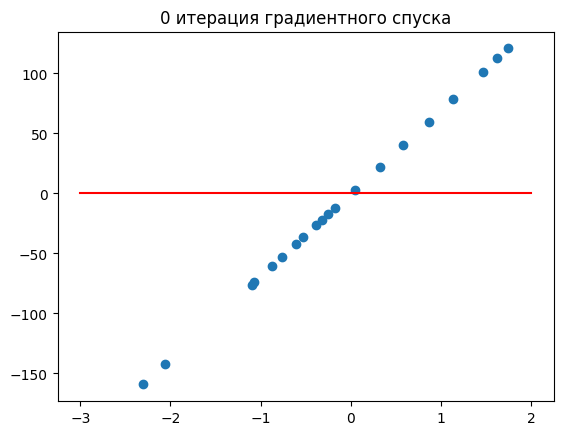

In [121]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)

plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.title("0 итерация градиентного спуска")
plt.show()

### Градиентный спуск (выравнивание коэффициентов потихоньку)

In [122]:
hyp.fit(x, y)
J = hyp.error(x, y)
print("Ошибка после градиентного спуска (1 итерация):", J)

Ошибка после градиентного спуска (1 итерация): 2253.745680891855


### Регрессия после 1 итерации градиентного спуска на полигоне значений

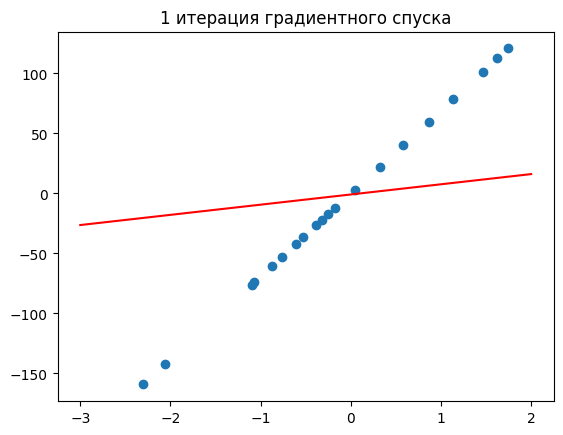

In [123]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)

plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.title("1 итерация градиентного спуска")
plt.show()

### Улучшение класса модели

In [124]:
class Model(object): # Улучшенная версия
    """Модель парной линейной регрессии"""

    def __init__(self, a=0, b=0):
        self.b0 = a
        self.b1 = b

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum(((self.predict(X) - Y) ** 2) / (2 * len(X)))

    def fit(self, X, Y, alpha=0.001, max_steps=10000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_err = self.error(X, Y)
            step += 1
            steps.append(step)
            errors.append(new_err)
        return steps, errors

### Итеративный градиентный спуск после улучшения

In [125]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print("Ошибка после улучшения модели:", J)

Ошибка после улучшения модели: 2.7769753060572152e-06


### Регрессия после 10000 итераций

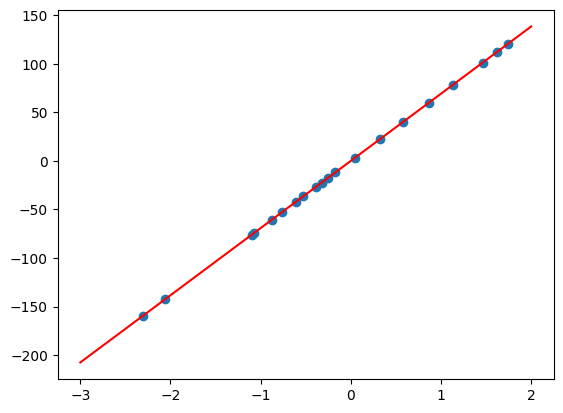

In [126]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)

plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

### График СКО-ошибки регрессии

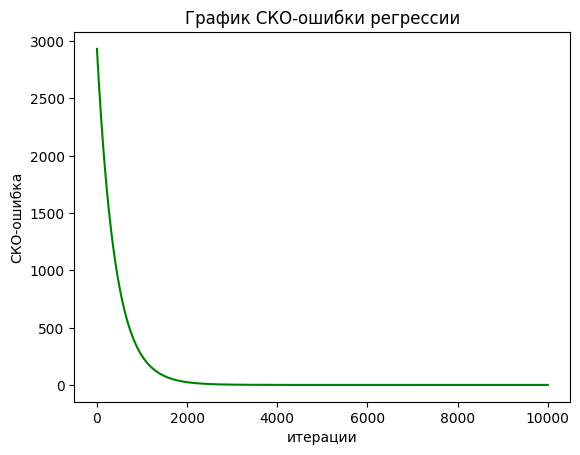

In [127]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.title("График СКО-ошибки регрессии")
plt.xlabel("итерации")
plt.ylabel("СКО-ошибка")
plt.show()

# =======================================================================================

# **Самостоятельные задания**

## 1. Различные начальные парамтеры a и b

In [128]:
hyp01 = Model(1, 7)
steps01, errors01 = hyp01.fit(x, y)

hyp02 = Model(-10, 57)
steps02, errors02 = hyp02.fit(x, y)

hyp03 = Model(-10061, -5089)
steps03, errors03 = hyp03.fit(x, y)

hyp04 = Model(10893, 5089)
steps04, errors04 = hyp04.fit(x, y)

### Графики регресии разных моделей с разными начальными параметрами

(-200.0, 150.0)

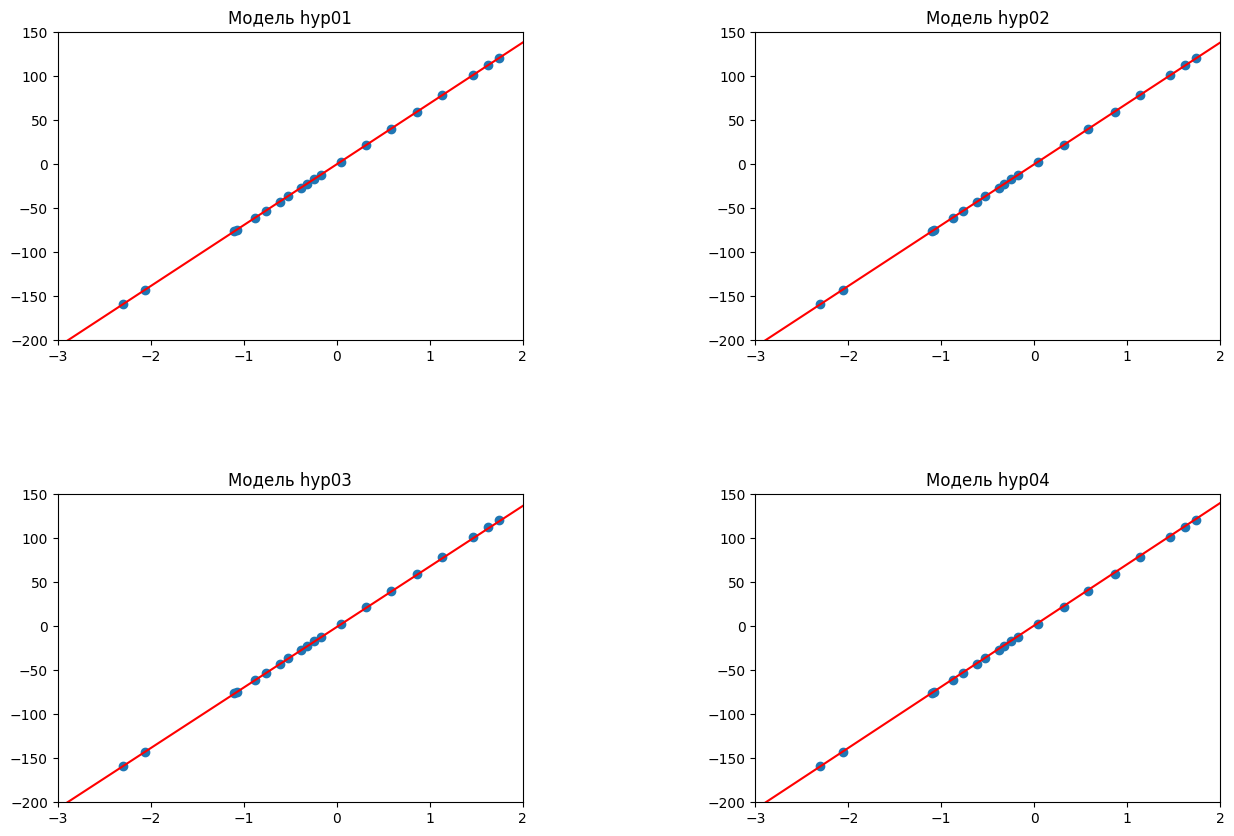

In [129]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

X = np.linspace(-3, 2, 100)

Y01 = hyp01.predict(X)
axes[0, 0].plot(X, Y01, 'r')
axes[0, 0].set_title("Модель hyp01")
axes[0, 0].scatter(x, y)
axes[0, 0].set_xlim(-3, 2)
axes[0, 0].set_ylim(-200, 150)

Y02 = hyp02.predict(X)
axes[0, 1].plot(X, Y02, 'r')
axes[0, 1].set_title("Модель hyp02")
axes[0, 1].scatter(x, y)
axes[0, 1].set_xlim(-3, 2)
axes[0, 1].set_ylim(-200, 150)

Y03 = hyp03.predict(X)
axes[1, 0].plot(X, Y03, 'r')
axes[1, 0].set_title("Модель hyp03")
axes[1, 0].scatter(x, y)
axes[1, 0].set_xlim(-3, 2)
axes[1, 0].set_ylim(-200, 150)

Y04 = hyp04.predict(X)
axes[1, 1].plot(X, Y04, 'r')
axes[1, 1].set_title("Модель hyp04")
axes[1, 1].scatter(x, y)
axes[1, 1].set_xlim(-3, 2)
axes[1, 1].set_ylim(-200, 150)

## Графики СКО-ошибок у моделей

(0.0, 1000.0)

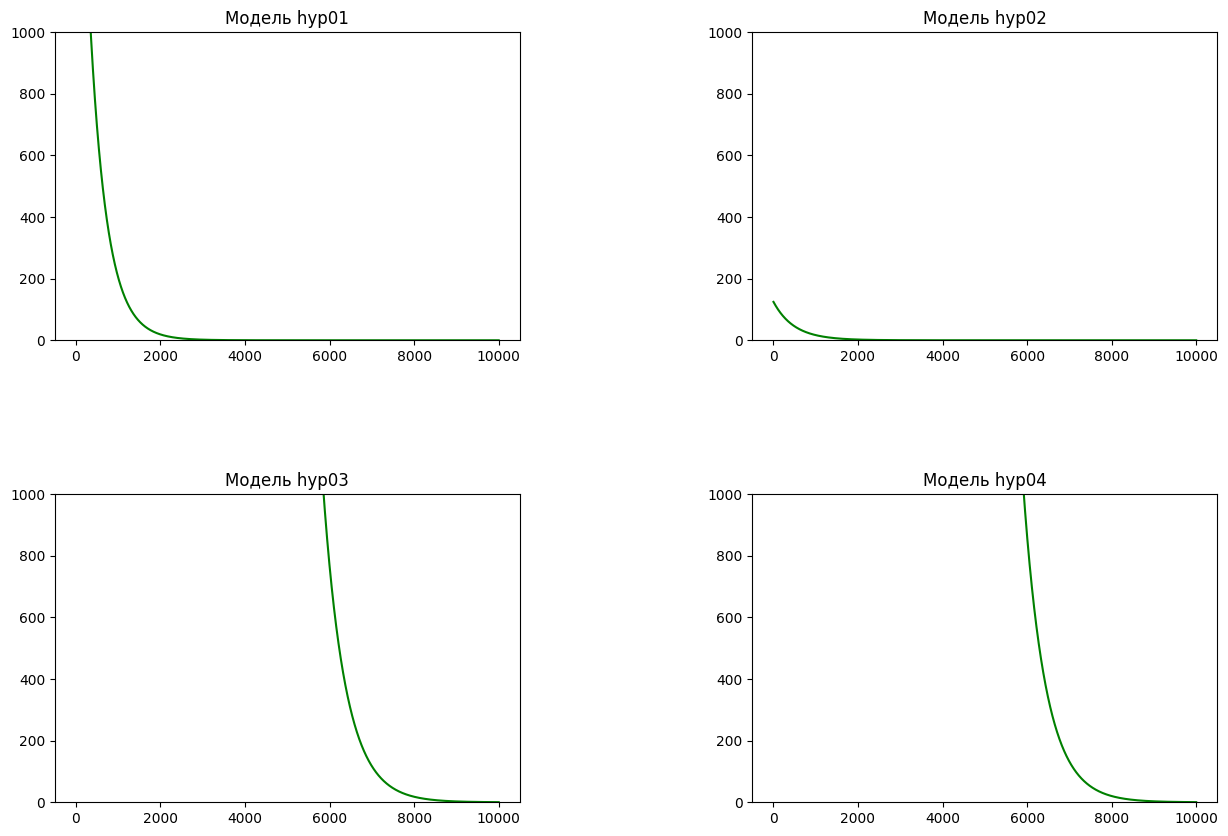

In [130]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

axes[0, 0].plot(steps01, errors01, 'g')
axes[0, 0].set_title("Модель hyp01")
axes[0, 0].set_ylim(0, 1000)

axes[0, 1].plot(steps02, errors02, 'g')
axes[0, 1].set_title("Модель hyp02")
axes[0, 1].set_ylim(0, 1000)

axes[1, 0].plot(steps03, errors03, 'g')
axes[1, 0].set_title("Модель hyp03")
axes[1, 0].set_ylim(0, 1000)

axes[1, 1].plot(steps04, errors04, 'g')
axes[1, 1].set_title("Модель hyp04")
axes[1, 1].set_ylim(0, 1000)

## 2. Различные параметры скорости обучения alpha

In [131]:
hyp1 = Model()
steps1, errors1 = hyp1.fit(x, y, alpha=0.001, max_steps=10000)

hyp2 = Model()
steps2, errors2 = hyp2.fit(x, y, alpha=0.009, max_steps=10000)

hyp3 = Model()
steps3, errors3 = hyp3.fit(x, y, alpha=0.1, max_steps=7000)

hyp4 = Model()
steps4, errors4 = hyp4.fit(x, y, alpha=0.0001, max_steps=100000)

hyp5 = Model()
steps5, errors5 = hyp5.fit(x, y, alpha=1, max_steps=5)

hyp6 = Model()
steps6, errors6 = hyp6.fit(x, y, alpha=0.6, max_steps=8000)

### Графики регресии разных моделей с разными начальными параметрами

(-200.0, 150.0)

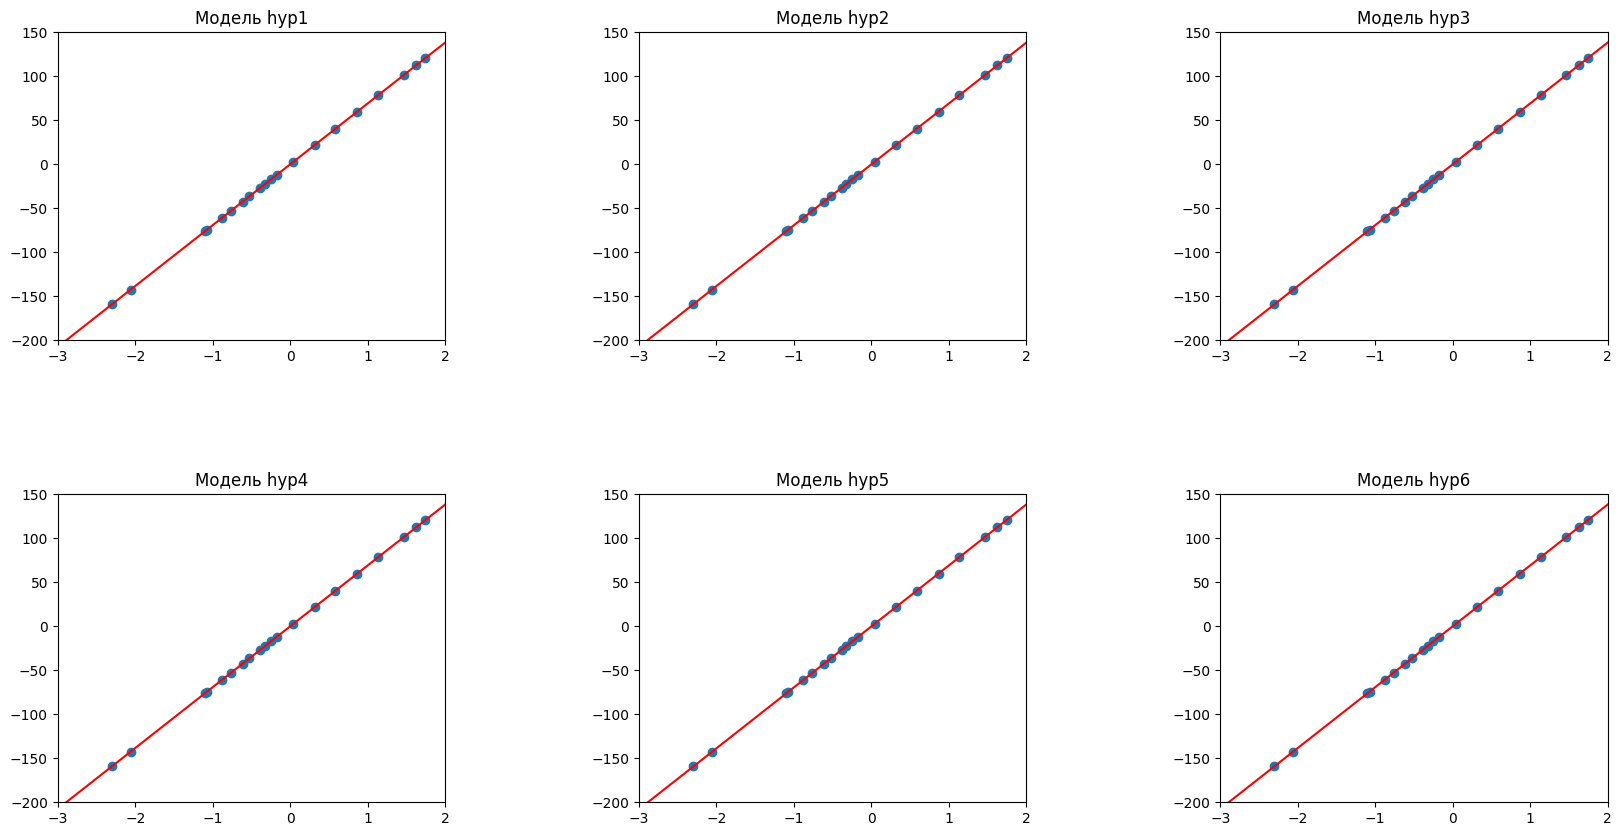

In [132]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

X = np.linspace(-3, 2, 100)

Y1 = hyp1.predict(X)
axes[0, 0].plot(X, Y1, 'r')
axes[0, 0].set_title("Модель hyp1")
axes[0, 0].scatter(x, y)
axes[0, 0].set_xlim(-3, 2)
axes[0, 0].set_ylim(-200, 150)

Y2 = hyp2.predict(X)
axes[0, 1].plot(X, Y2, 'r')
axes[0, 1].set_title("Модель hyp2")
axes[0, 1].scatter(x, y)
axes[0, 1].set_xlim(-3, 2)
axes[0, 1].set_ylim(-200, 150)

Y3 = hyp3.predict(X)
axes[0, 2].plot(X, Y3, 'r')
axes[0, 2].set_title("Модель hyp3")
axes[0, 2].scatter(x, y)
axes[0, 2].set_xlim(-3, 2)
axes[0, 2].set_ylim(-200, 150)

Y4 = hyp4.predict(X)
axes[1, 0].plot(X, Y4, 'r')
axes[1, 0].set_title("Модель hyp4")
axes[1, 0].scatter(x, y)
axes[1, 0].set_xlim(-3, 2)
axes[1, 0].set_ylim(-200, 150)

Y5 = hyp5.predict(X)
axes[1, 1].plot(X, Y5, 'r')
axes[1, 1].set_title("Модель hyp5")
axes[1, 1].scatter(x, y)
axes[1, 1].set_xlim(-3, 2)
axes[1, 1].set_ylim(-200, 150)

Y6 = hyp6.predict(X)
axes[1, 2].plot(X, Y6, 'r')
axes[1, 2].set_title("Модель hyp6")
axes[1, 2].scatter(x, y)
axes[1, 2].set_xlim(-3, 2)
axes[1, 2].set_ylim(-200, 150)

## Графики СКО-ошибок у моделей

Text(0.5, 1.0, 'Модель hyp6')

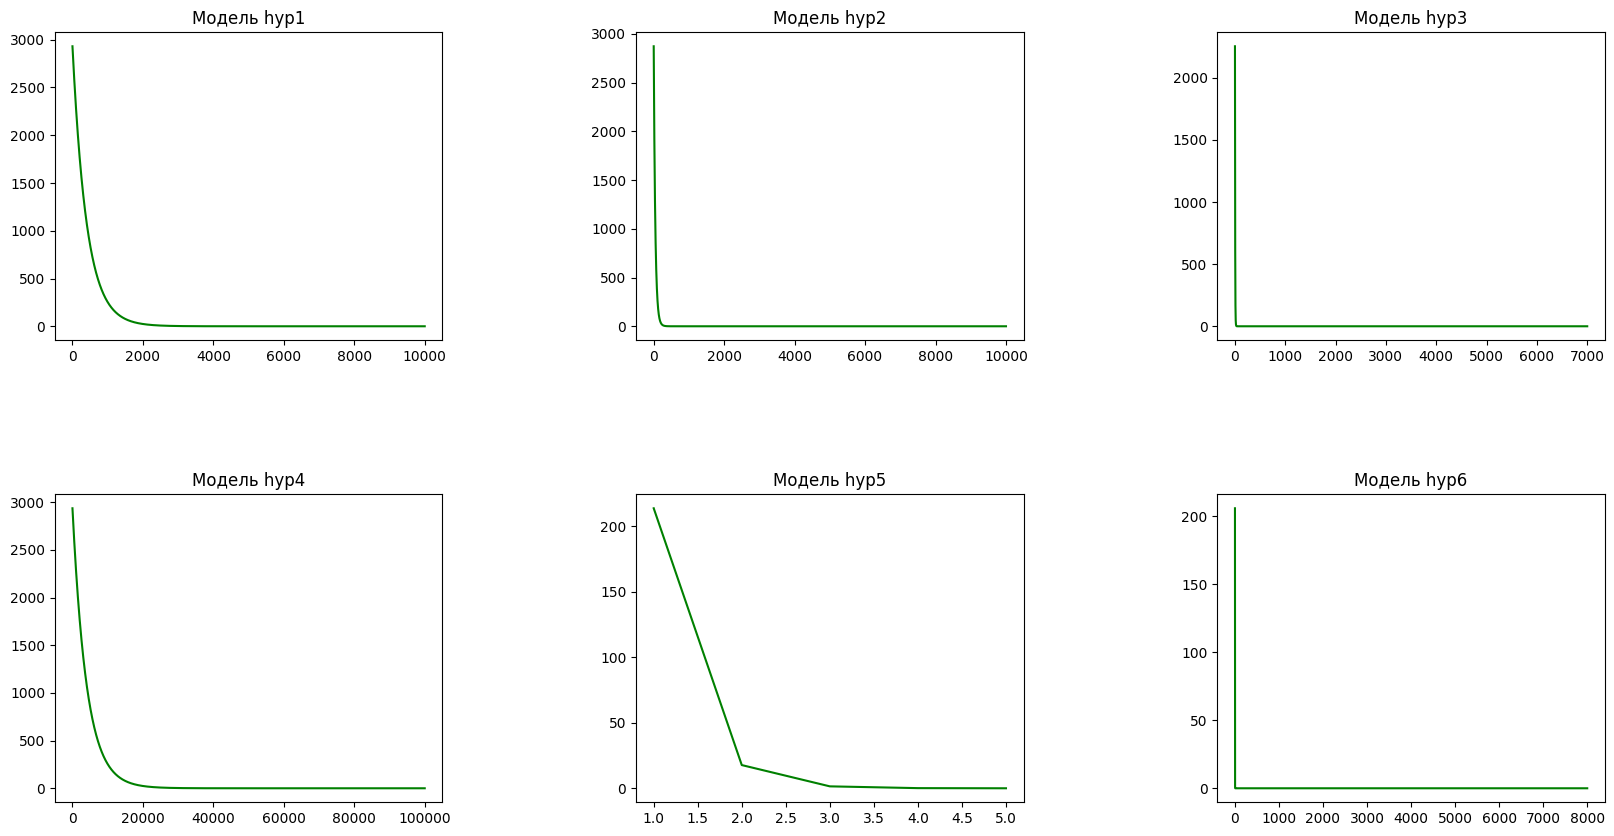

In [133]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

axes[0, 0].plot(steps1, errors1, 'g')
axes[0, 0].set_title("Модель hyp1")

axes[0, 1].plot(steps2, errors2, 'g')
axes[0, 1].set_title("Модель hyp2")

axes[0, 2].plot(steps3, errors3, 'g')
axes[0, 2].set_title("Модель hyp3")

axes[1, 0].plot(steps4, errors4, 'g')
axes[1, 0].set_title("Модель hyp4")

axes[1, 1].plot(steps5, errors5, 'g')
axes[1, 1].set_title("Модель hyp5")

axes[1, 2].plot(steps6, errors6, 'g')
axes[1, 2].set_title("Модель hyp6")

## 3. Модификация для DataFrame

In [134]:
def DFtoSeries(x, y):
    xv = x.values
    yv = y.values
    dx = pd.DataFrame(xv)
    dy = pd.DataFrame(yv)
    rx = dx[1]
    ry = dy[1]
    return rx, ry


x, y = DFtoSeries(x0, y0)
print(x)
print()
print(y)

0     1.462108
1     1.133769
2    -2.301539
3     1.744812
4     0.042214
5    -0.611756
6     0.319039
7    -0.761207
8     0.582815
9    -1.099891
10    0.865408
11    1.624345
12   -0.528172
13   -0.249370
14   -1.072969
15   -0.384054
16   -0.172428
17   -0.322417
18   -2.060141
19   -0.877858
Name: 1, dtype: float64

0     101.159902
1      78.442913
2    -159.238195
3     120.719533
4       2.920673
5     -42.326026
6      22.073585
7     -52.666163
8      40.323651
9     -76.098960
10     59.875573
11    112.384738
12    -36.542995
13    -17.253366
14    -74.236243
15    -26.571842
16    -11.929913
17    -22.307308
18   -142.536421
19    -60.737015
Name: 1, dtype: float64


## 4. - 5. Модернизация метода градиентового спуска

In [135]:
class Model(object): # Улучшенная версия
    """Модель парной линейной регрессии"""

    def __init__(self, a=0, b=0):
        self.b0 = a
        self.b1 = b

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum(((self.predict(X) - Y) ** 2) / (2 * len(X)))

    def fit(self, X, Y, alpha=0.001, accuracy=0.000001, max_steps=10000):
        steps, errors = [], []
        step = 0
        err = float('inf')
        for _ in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_err = self.error(X, Y)
            step += 1
            steps.append(step)
            errors.append(new_err)
            if err < new_err or abs(new_err - err) <= accuracy:
                break
            err = new_err
        return steps, errors

### Проверяем на некоторых предыдущих моделях

In [136]:
hyp1 = Model()
steps1, errors1 = hyp1.fit(x, y)
if len(steps1) == 10000:
    print(f"\nМодель прекратила обучаться на {steps1[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps1[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors1[-2] - errors1[-11]}")

hyp2 = Model()
steps2, errors2 = hyp2.fit(x, y, alpha=0.009, max_steps=10000)
if len(steps2) == 10000:
    print(f"\nМодель прекратила обучаться на {steps2[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps2[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors2[-2] - errors2[-1]}")

hyp3 = Model()
steps3, errors3 = hyp3.fit(x, y, alpha=0.1, max_steps=7000)
if len(steps3) == 7000:
    print(f"\nМодель прекратила обучаться на {steps3[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps3[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors3[-2] - errors3[-1]}")

hyp4 = Model()
steps4, errors4 = hyp4.fit(x, y, alpha=0.0001, max_steps=100000)
if len(steps4) == 100000:
    print(f"\nМодель прекратила обучаться на {steps4[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps4[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors4[-2] - errors4[-1]}")

hyp5 = Model()
steps5, errors5 = hyp5.fit(x, y, alpha=1, max_steps=100)
if len(steps5) == 100:
    print(f"\nМодель прекратила обучаться на {steps5[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps5[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors5[-2] - errors5[-1]}")

hyp6 = Model()
steps6, errors6 = hyp6.fit(x, y, alpha=0.6, max_steps=8000)
if len(steps6) == 8000:
    print(f"\nМодель прекратила обучаться на {steps6[-1]} шаге, так как достигнуто максимальное заданное количество шагов")
else:
    print(f"\nМодель прекратила обучаться на {steps6[-1]} шаге, так как разность ошибок соседних шагов меньше заданной точности и равна {errors6[-2] - errors6[-1]}")


Модель прекратила обучаться на 7227 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна -9.086423072526936e-06

Модель прекратила обучаться на 929 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна 9.894447688538202e-07

Модель прекратила обучаться на 93 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна 9.476459663731647e-07

Модель прекратила обучаться на 60382 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна 9.99960977763302e-07

Модель прекратила обучаться на 10 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна 4.5865250095940697e-07

Модель прекратила обучаться на 13 шаге, так как разность ошибок соседних шагов меньше заданной точности и равна 7.483630956779711e-07


### Графики регресии этих моделей

(-200.0, 150.0)

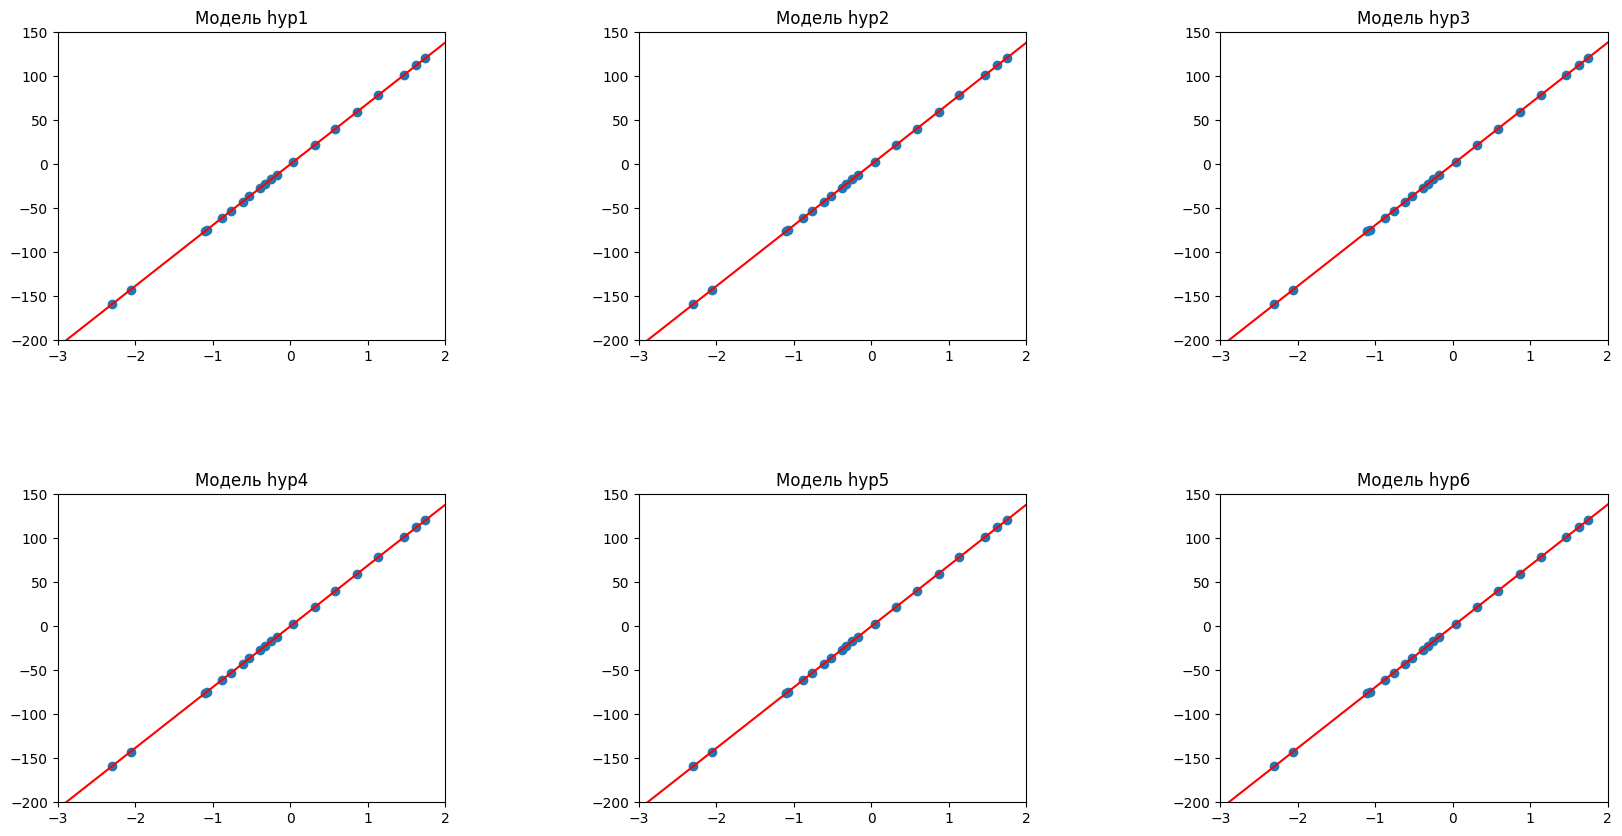

In [137]:
### Графики регресии разных моделей с разными начальными параметрами
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

X = np.linspace(-3, 2, 100)

Y1 = hyp1.predict(X)
axes[0, 0].plot(X, Y1, 'r')
axes[0, 0].set_title("Модель hyp1")
axes[0, 0].scatter(x, y)
axes[0, 0].set_xlim(-3, 2)
axes[0, 0].set_ylim(-200, 150)

Y2 = hyp2.predict(X)
axes[0, 1].plot(X, Y2, 'r')
axes[0, 1].set_title("Модель hyp2")
axes[0, 1].scatter(x, y)
axes[0, 1].set_xlim(-3, 2)
axes[0, 1].set_ylim(-200, 150)

Y3 = hyp3.predict(X)
axes[0, 2].plot(X, Y3, 'r')
axes[0, 2].set_title("Модель hyp3")
axes[0, 2].scatter(x, y)
axes[0, 2].set_xlim(-3, 2)
axes[0, 2].set_ylim(-200, 150)

Y4 = hyp4.predict(X)
axes[1, 0].plot(X, Y4, 'r')
axes[1, 0].set_title("Модель hyp4")
axes[1, 0].scatter(x, y)
axes[1, 0].set_xlim(-3, 2)
axes[1, 0].set_ylim(-200, 150)

Y5 = hyp5.predict(X)
axes[1, 1].plot(X, Y5, 'r')
axes[1, 1].set_title("Модель hyp5")
axes[1, 1].scatter(x, y)
axes[1, 1].set_xlim(-3, 2)
axes[1, 1].set_ylim(-200, 150)

Y6 = hyp6.predict(X)
axes[1, 2].plot(X, Y6, 'r')
axes[1, 2].set_title("Модель hyp6")
axes[1, 2].scatter(x, y)
axes[1, 2].set_xlim(-3, 2)
axes[1, 2].set_ylim(-200, 150)

## Графики СКО-ошибок у моделей

Text(0.5, 1.0, 'Модель hyp6')

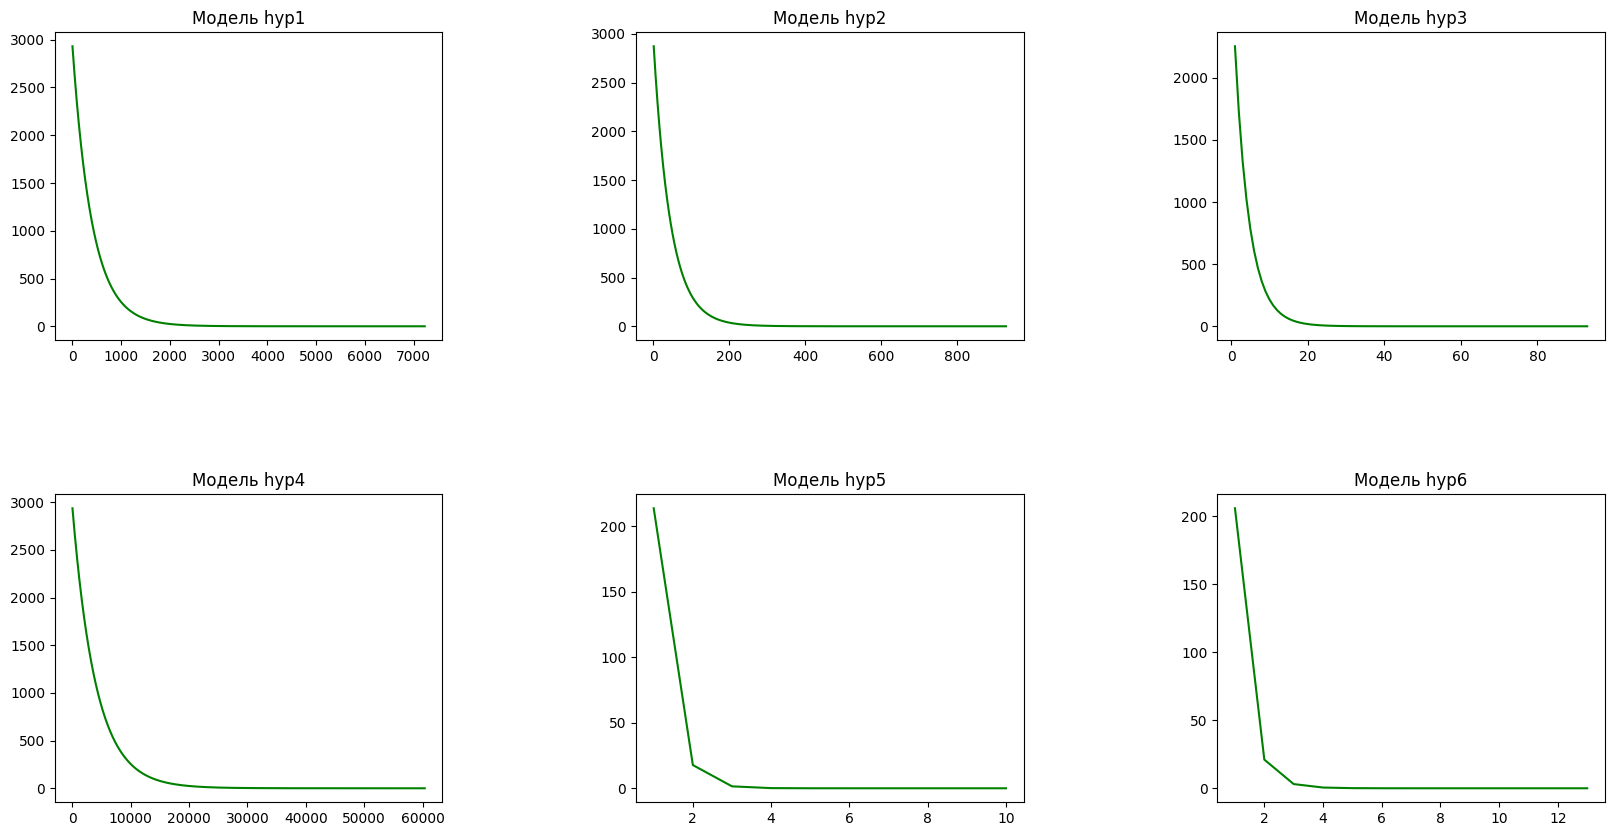

In [138]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
plt.subplots_adjust(wspace=0.5, hspace=0.5)

axes[0, 0].plot(steps1, errors1, 'g')
axes[0, 0].set_title("Модель hyp1")

axes[0, 1].plot(steps2, errors2, 'g')
axes[0, 1].set_title("Модель hyp2")

axes[0, 2].plot(steps3, errors3, 'g')
axes[0, 2].set_title("Модель hyp3")

axes[1, 0].plot(steps4, errors4, 'g')
axes[1, 0].set_title("Модель hyp4")

axes[1, 1].plot(steps5, errors5, 'g')
axes[1, 1].set_title("Модель hyp5")

axes[1, 2].plot(steps6, errors6, 'g')
axes[1, 2].set_title("Модель hyp6")

##  6. - 7. Адаптивная скорость обучения & Автоматическое создание графиков

In [139]:
class Model(object):  # Улучшенная версия с адаптивной скоростью обучения
    """Модель парной линейной регрессии"""


    def __init__(self, a=0, b=0):
        self.b0 = a
        self.b1 = b


    def predict(self, X):
        return self.b0 + self.b1 * X


    def error(self, X, Y):
        return sum(((self.predict(X) - Y) ** 2) / (2 * len(X)))


    def Draw(self): # Рисует обычный график регрессии модели на полигоне значений
        xd = np.linspace(-3, 2, 100)
        yd = self.predict(xd)

        plt.figure()
        plt.scatter(x, y)
        plt.title("Регрессия модели на полигоне значений")
        plt.plot(xd, yd, 'r')
        plt.show()


    def DrawError(self, steps, errors):
        plt.figure()
        plt.plot(steps, errors, 'g')
        plt.title("График СКО-ошибки регрессии")
        plt.xlabel("итерации")
        plt.ylabel("СКО-ошибка")
        plt.show()


    def fit(self, X, Y, alpha=15, accuracy=0.000001, max_steps=10000):
        errors = []
        alphas = []
        steps = []
        bb0 = self.b0
        bb1 = self.b1
        breakpoint = True

        while breakpoint:
            self.b0, self.b1 = bb0, bb1
            error = self.error(X, Y)
            cur_err = [error]
            cur_a = [alpha]
            cur_s = [0]

            for step in range(1, max_steps + 1):
                dJ0 = sum(self.predict(X) - Y) / len(X)
                dJ1 = sum((self.predict(X) - Y) * X) / len(X)

                self.b0 -= alpha * dJ0
                self.b1 -= alpha * dJ1

                new_err = self.error(X, Y)
                cur_err.append(new_err)
                cur_s.append(step)

                if new_err > error:
                    alpha /= 2
                    errors.append(cur_err)
                    alphas.append(cur_a)
                    steps.append(cur_s)
                    break

                if abs(new_err - error) <= accuracy:
                    errors.append(cur_err)
                    alphas.append(cur_a)
                    steps.append(cur_s)
                    breakpoint = False
                    break

                error = new_err

            else:
                errors.append(cur_err)
                alphas.append(cur_a)
                steps.append(cur_s)
                break

        return steps, errors, alphas

### Проверка улучшенной автообучаемой модели с рисованием графиков

1. alpha = 15: [2937.6446095153397, 922275.4440517082]
2. alpha = 7.5: [2937.6446095153397, 205411.24934679072]
3. alpha = 3.75: [2937.6446095153397, 39875.62323219777]
4. alpha = 1.875: [2937.6446095153397, 5331.9279843677405]
5. alpha = 0.9375: [2937.6446095153397, 116.10981281933675, 4.875727200221546, 0.2092912879057927, 0.009051807340148424, 0.00039248204248733975, 1.703224071498522e-05, 7.393434848046625e-07, 3.209678218092728e-08]





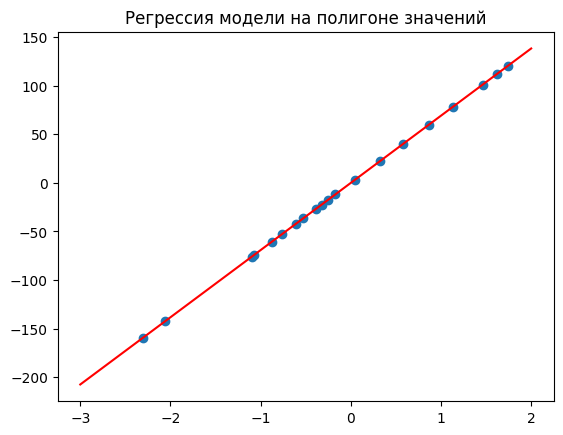

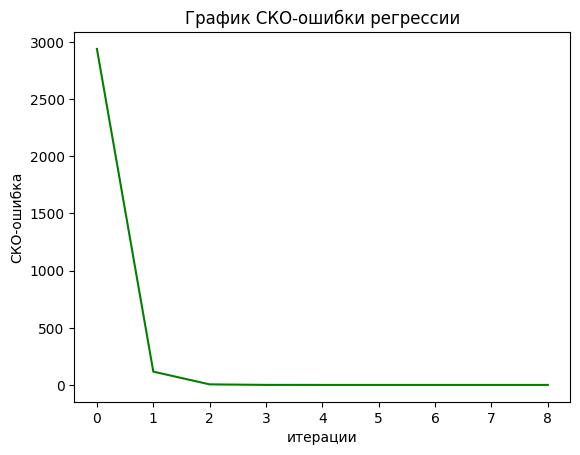

In [140]:
h = Model()
steps, errors, alphas = h.fit(x, y)


for i in range(len(alphas)):
    print(f"{i + 1}. alpha = {alphas[i][0]}: {errors[i]}")

print()
print()
print()

h.Draw()

print()
print()
print()

i = 4
h.DrawError(steps[i], errors[i])